In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
fund_master = pd.read_csv("data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
benchmark = pd.read_csv("data/processed/10_benchmark_indices_clean.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
print("Fund Master Shape:", fund_master.shape)
print("NAV Shape:", nav.shape)
print("Performance Shape:", performance.shape)
print("Benchmark Shape:", benchmark.shape)

Fund Master Shape: (40, 15)
NAV Shape: (46000, 3)
Performance Shape: (40, 19)
Benchmark Shape: (8050, 3)


In [4]:
print("Fund Master Columns")
print(fund_master.columns)

print("\nNAV Columns")
print(nav.columns)

print("\nPerformance Columns")
print(performance.columns)

print("\nBenchmark Columns")
print(benchmark.columns)

Fund Master Columns
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code'], dtype='str')

NAV Columns
Index(['amfi_code', 'date', 'nav'], dtype='str')

Performance Columns
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade'], dtype='str')

Benchmark Columns
Index(['date', 'index_name', 'close_value'], dtype='str')


In [5]:
# Convert Date Columns

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Date Conversion Completed!")

Date Conversion Completed!


In [6]:
# Task 1 - Daily Returns

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head(15))

    amfi_code       date       nav  daily_return
0      100016 2022-01-03  520.4608           NaN
1      100016 2022-01-04  515.0971     -0.010306
2      100016 2022-01-05  521.7239      0.012865
3      100016 2022-01-06  515.7880     -0.011377
4      100016 2022-01-07  515.1639     -0.001210
5      100016 2022-01-10  510.7136     -0.008639
6      100016 2022-01-11  513.5542      0.005562
7      100016 2022-01-12  512.3195     -0.002404
8      100016 2022-01-13  510.2445     -0.004050
9      100016 2022-01-14  514.3636      0.008073
10     100016 2022-01-17  514.7627      0.000776
11     100016 2022-01-18  517.3803      0.005085
12     100016 2022-01-19  513.1866     -0.008106
13     100016 2022-01-20  507.1294     -0.011803
14     100016 2022-01-21  507.8710      0.001462


In [7]:
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


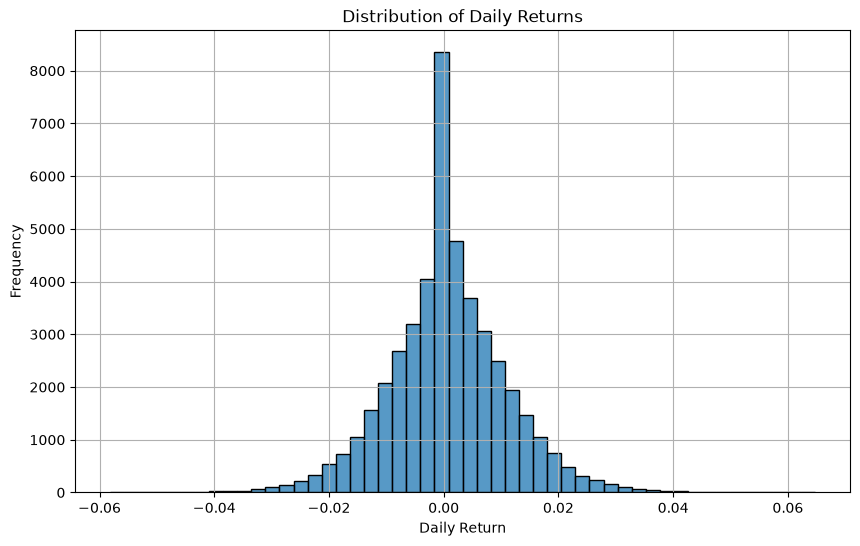

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.savefig(
    "charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade'], dtype='str')


In [10]:
# Task 2 - CAGR Comparison Table

cagr = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "category",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]].copy()

cagr.head()

,amfi_code,scheme_name,fund_house,category,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,5.34,6.07,5.43


In [11]:
print(cagr)

    amfi_code                                        scheme_name                fund_house         category  return_1yr_pct  return_3yr_pct  return_5yr_pct
0      119551          SBI Bluechip Fund - Regular Plan - Growth           SBI Mutual Fund        Large Cap           12.42           12.36           14.45
1      119552           SBI Bluechip Fund - Direct Plan - Growth           SBI Mutual Fund        Large Cap           15.25           11.30           14.23
2      119598         SBI Small Cap Fund - Regular Plan - Growth           SBI Mutual Fund        Small Cap           24.56           23.39           20.67
3      119599          SBI Small Cap Fund - Direct Plan - Growth           SBI Mutual Fund        Small Cap           20.59           23.14           21.82
4      119120       SBI Magnum Gilt Fund - Regular Plan - Growth           SBI Mutual Fund             Gilt            5.34            6.07            5.43
5      100016          HDFC Top 100 Fund - Regular Plan - Growth

In [12]:
top5 = cagr.sort_values(
    by="return_5yr_pct",
    ascending=False
)

top5.head(10)

,amfi_code,scheme_name,fund_house,category,return_1yr_pct,return_3yr_pct,return_5yr_pct
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,24.93,22.38,23.80
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,21.97,20.98,22.62
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,21.30,20.15,21.88
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,20.59,23.14,21.82
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,24.56,23.39,20.67
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,20.20,20.08,20.61
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,14.12,17.16,19.00
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,14.88,15.18,18.94
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,17.12,18.23,17.75
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,15.43,16.58,17.69


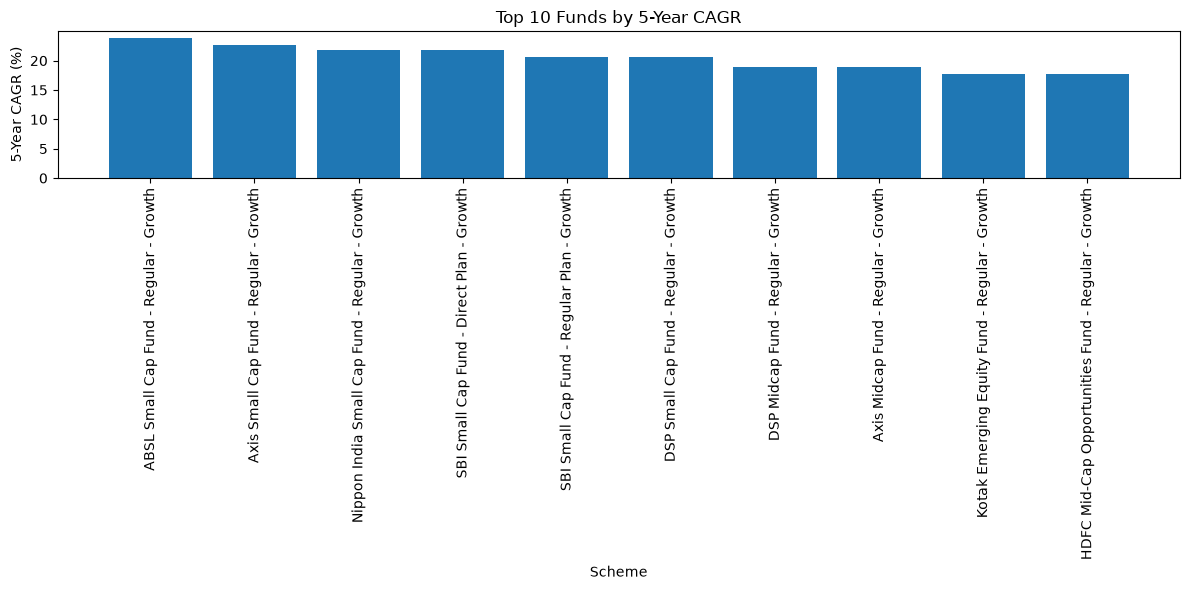

In [13]:
import matplotlib.pyplot as plt

top10 = top5.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["return_5yr_pct"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by 5-Year CAGR")
plt.xlabel("Scheme")
plt.ylabel("5-Year CAGR (%)")

plt.tight_layout()

plt.savefig(
    "charts/top10_5yr_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
cagr.to_csv(
    "reports/cagr_comparison.csv",
    index=False
)

print("CAGR Comparison Table Saved Successfully!")

CAGR Comparison Table Saved Successfully!


## Insight 2

The comparison of 1-year, 3-year, and 5-year returns shows that long-term performance varies across mutual fund schemes. Funds with consistently higher 5-year returns demonstrate stronger long-term growth potential and investment performance.

In [15]:
# Task 3 - Sharpe Ratio

risk_free_rate = 6.5

performance["calculated_sharpe"] = (
    (performance["return_1yr_pct"] - risk_free_rate)
    / performance["std_dev_ann_pct"]
) * np.sqrt(252)

performance[[
    "scheme_name",
    "return_1yr_pct",
    "std_dev_ann_pct",
    "calculated_sharpe"
]].head()

,scheme_name,return_1yr_pct,std_dev_ann_pct,calculated_sharpe
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,14.0,6.712649
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,14.0,9.921567
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,25.0,11.467744
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,25.0,8.946873
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,4.0,-4.603607


In [16]:
sharpe_rank = performance[[
    "scheme_name",
    "fund_house",
    "return_1yr_pct",
    "std_dev_ann_pct",
    "calculated_sharpe"
]].copy()

sharpe_rank = sharpe_rank.sort_values(
    by="calculated_sharpe",
    ascending=False
)

sharpe_rank.head(10)

,scheme_name,fund_house,return_1yr_pct,std_dev_ann_pct,calculated_sharpe
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,8.89,0.5,75.880148
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,24.93,25.0,11.702687
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,24.56,25.0,11.467744
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,19.98,19.0,11.262546
33,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,17.43,16.0,10.844273
13,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,16.67,15.0,10.762916
15,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,15.84,14.0,10.590565
10,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,15.63,14.0,10.352447
1,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,15.25,14.0,9.921567
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,21.97,25.0,9.823145


In [17]:
sharpe_rank.to_csv(
    "reports/sharpe_ratio_ranking.csv",
    index=False
)

print("Sharpe Ratio Ranking Saved Successfully!")

Sharpe Ratio Ranking Saved Successfully!


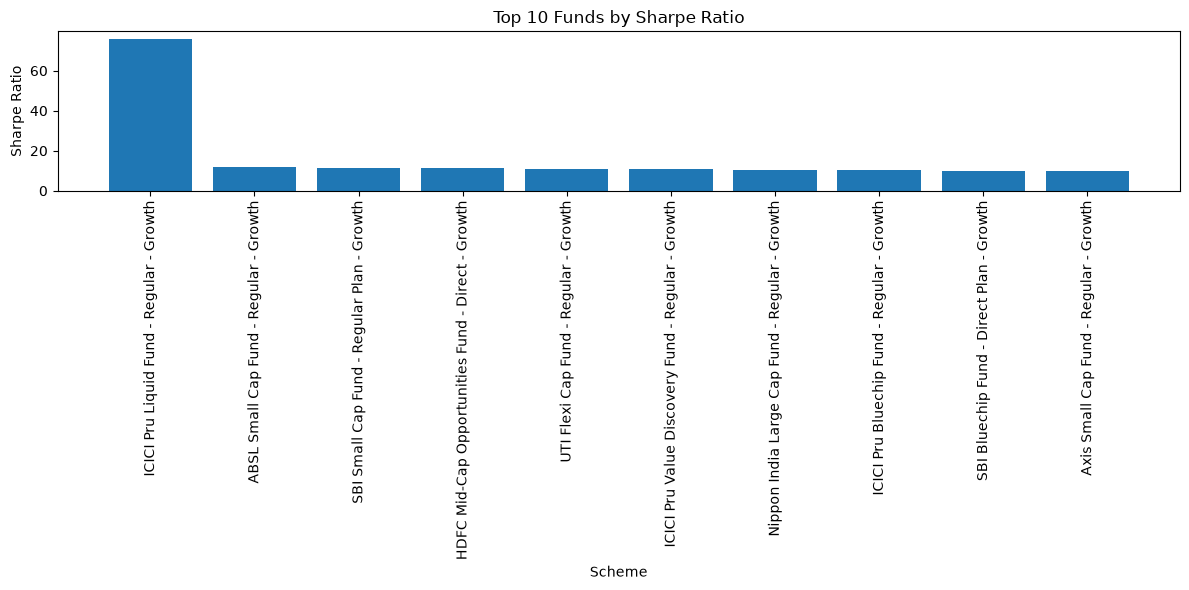

In [18]:
plt.figure(figsize=(12,6))

top10 = sharpe_rank.head(10)

plt.bar(
    top10["scheme_name"],
    top10["calculated_sharpe"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Scheme")
plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "charts/sharpe_ratio_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 3

The Sharpe Ratio measures risk-adjusted returns by comparing excess returns over the risk-free rate to the fund's volatility. Funds with higher Sharpe Ratios provide better returns for each unit of risk and are generally considered more efficient investments.

In [19]:
# Task 4 - Sortino Ratio

risk_free_rate = 0.065 / 252  
sortino_results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < risk_free_rate]

    downside_std = downside.std()

    avg_return = returns.mean()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((avg_return - risk_free_rate) / downside_std) * np.sqrt(252)

    sortino_results.append([code, sortino])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "calculated_sortino"]
)

sortino_df.head()

,amfi_code,calculated_sortino
0,100016,-0.348196
1,100025,-0.915371
2,100033,1.823824
3,101206,1.785592
4,101207,0.274615


In [20]:
sortino_df = sortino_df.merge(
    performance[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code"
)

sortino_df.head()

,amfi_code,calculated_sortino,scheme_name,fund_house
0,100016,-0.348196,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.915371,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,1.823824,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,1.785592,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.274615,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [21]:
sortino_rank = sortino_df.sort_values(
    by="calculated_sortino",
    ascending=False
)

sortino_rank.head(10)

,amfi_code,calculated_sortino,scheme_name,fund_house
34,148567,2.368342,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
30,120843,2.352942,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
36,148569,2.135083,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
19,119551,2.103952,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
25,120505,2.010035,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
38,149323,1.868935,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
9,118632,1.839859,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
2,100033,1.823824,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,1.785592,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
24,120504,1.785043,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF


In [22]:
sortino_rank.to_csv(
    "reports/sortino_ratio_ranking.csv",
    index=False
)

print("Sortino Ratio Ranking Saved Successfully!")

Sortino Ratio Ranking Saved Successfully!


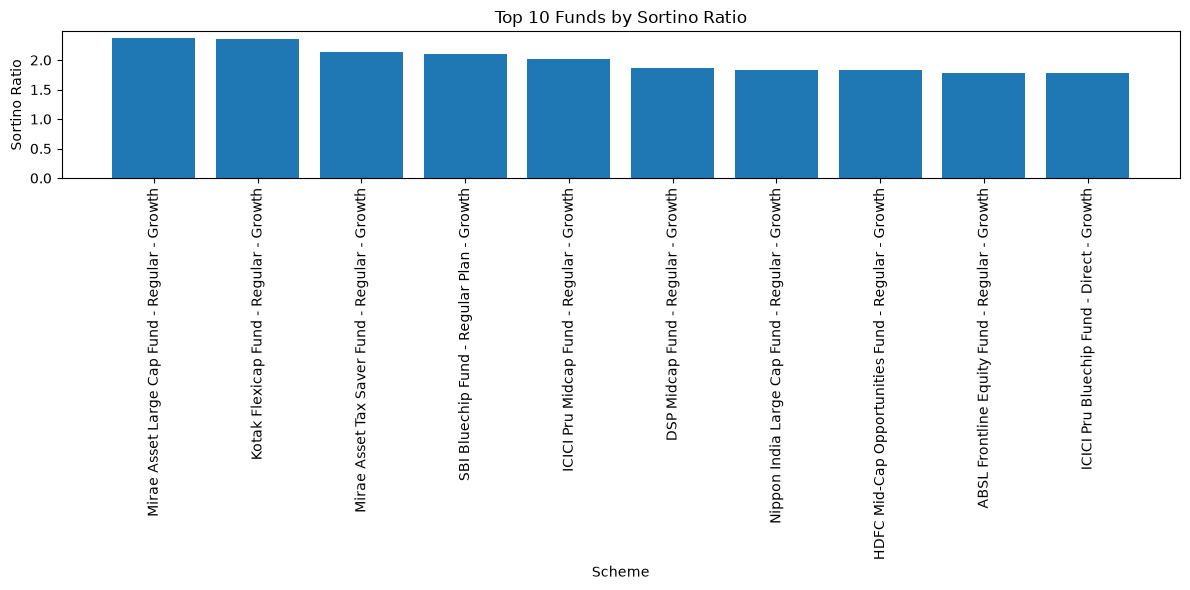

In [23]:
plt.figure(figsize=(12,6))

top10 = sortino_rank.head(10)

plt.bar(
    top10["scheme_name"],
    top10["calculated_sortino"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Scheme")
plt.ylabel("Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "charts/sortino_ratio_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 4

The Sortino Ratio evaluates risk-adjusted performance by considering only downside volatility. Funds with higher Sortino Ratios have generated better returns while minimizing harmful downside risk, making them attractive for long-term investors.

In [24]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [25]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [26]:
# Task 5 - Alpha & Beta

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [27]:
alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    fund = group[["date", "daily_return"]].copy()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 20:
        continue

    slope, intercept, r, p, stderr = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append([
        code,
        alpha,
        beta
    ])

In [28]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [29]:
alpha_beta_df.to_csv(
    "reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta CSV Saved Successfully!")

Alpha & Beta CSV Saved Successfully!


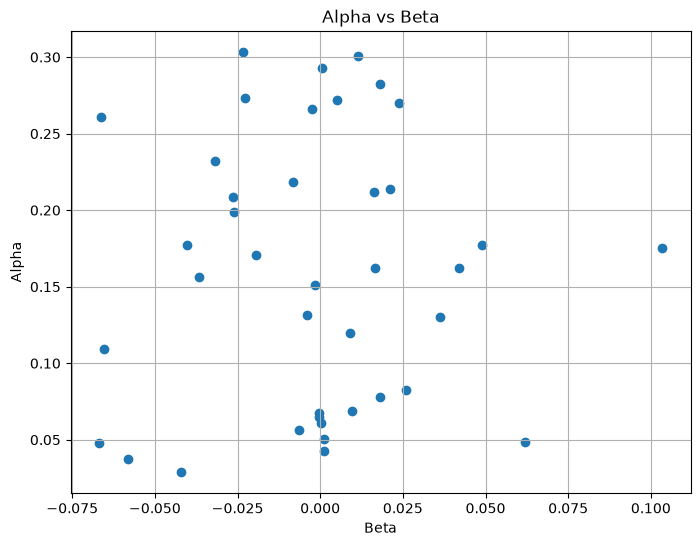

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    alpha_beta_df["beta"],
    alpha_beta_df["alpha"]
)

plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Alpha vs Beta")

plt.grid(True)

plt.savefig(
    "charts/alpha_beta.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 5

Alpha measures the excess return generated by a fund relative to the benchmark, while Beta measures the fund's sensitivity to market movements. Funds with positive Alpha and Beta close to 1 generally indicate good performance with market-like risk exposure.

In [31]:
# Task 6 - Maximum Drawdown

drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (group["nav"] / group["running_max"]) - 1

    worst_row = group.loc[group["drawdown"].idxmin()]

    drawdown_results.append({
        "amfi_code": code,
        "max_drawdown": worst_row["drawdown"],
        "worst_date": worst_row["date"]
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,max_drawdown,worst_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [32]:
drawdown_df = drawdown_df.merge(
    performance[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code"
)

drawdown_df.head()

,amfi_code,max_drawdown,worst_date,scheme_name,fund_house
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [33]:
drawdown_rank = drawdown_df.sort_values(
    by="max_drawdown"
)

drawdown_rank.head(10)

,amfi_code,max_drawdown,worst_date,scheme_name,fund_house
22,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
17,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
39,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
21,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
7,102886,-0.280011,2026-04-27,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
29,120842,-0.240035,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF
11,118634,-0.233449,2026-02-20,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF
15,119093,-0.217514,2023-05-22,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund


In [34]:
drawdown_rank.to_csv(
    "reports/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown Report Saved Successfully!")

Maximum Drawdown Report Saved Successfully!


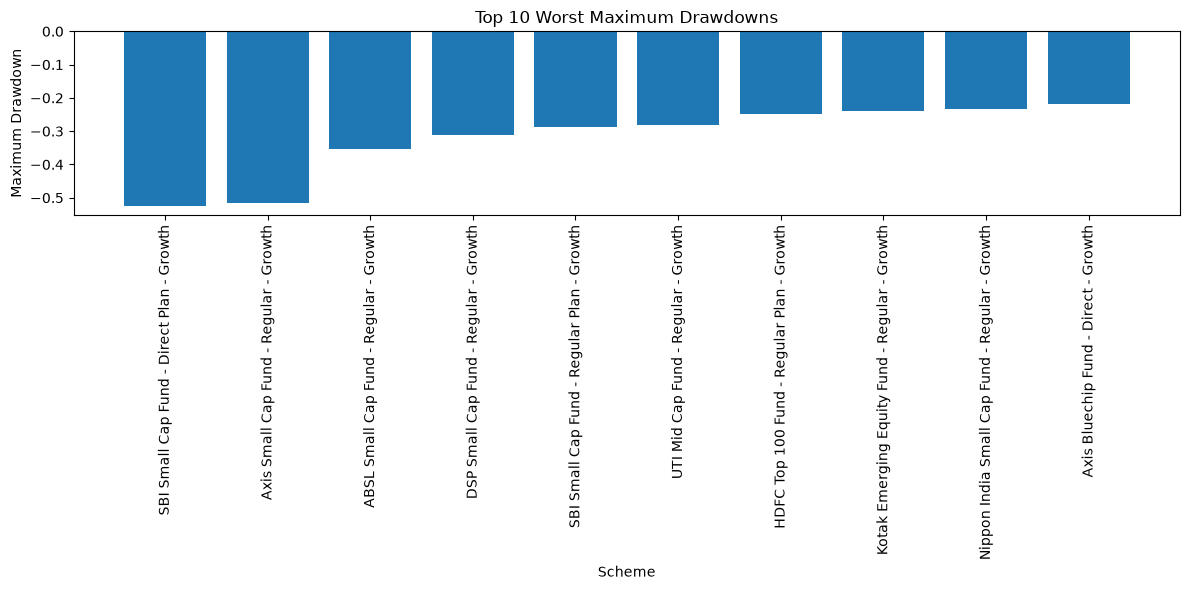

In [35]:
import matplotlib.pyplot as plt

worst10 = drawdown_rank.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    worst10["scheme_name"],
    worst10["max_drawdown"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Worst Maximum Drawdowns")
plt.xlabel("Scheme")
plt.ylabel("Maximum Drawdown")

plt.tight_layout()

plt.savefig(
    "charts/max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 6

Maximum Drawdown measures the largest decline in a fund's NAV from its historical peak. Funds with smaller drawdowns demonstrate better resilience during market downturns and lower downside risk.

In [36]:
# Task 7 - Fund Scorecard

scorecard = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "return_3yr_pct",
    "expense_ratio_pct"
]].copy()

scorecard = scorecard.merge(
    sharpe_rank[["scheme_name", "calculated_sharpe"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    alpha_beta_df[["scheme_name", "alpha"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    drawdown_df[["scheme_name", "max_drawdown"]],
    on="scheme_name"
)

scorecard.head()

KeyError: "['scheme_name'] not in index"

In [37]:
print(alpha_beta_df.columns)

Index(['amfi_code', 'alpha', 'beta'], dtype='str')


In [38]:
alpha_beta_df = alpha_beta_df.merge(
    performance[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)

print(alpha_beta_df.columns)

Index(['amfi_code', 'alpha', 'beta', 'scheme_name', 'fund_house'], dtype='str')


In [39]:
scorecard = scorecard.merge(
    alpha_beta_df[["scheme_name", "alpha"]],
    on="scheme_name",
    how="left"
)

In [40]:
print(alpha_beta_df.columns)

Index(['amfi_code', 'alpha', 'beta', 'scheme_name', 'fund_house'], dtype='str')


In [41]:

# Task 7 - Fund Scorecard

scorecard = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "return_3yr_pct",
    "expense_ratio_pct"
]].copy()

scorecard = pd.merge(
    scorecard,
    sharpe_rank[["scheme_name", "calculated_sharpe"]],
    on="scheme_name",
    how="left"
)

scorecard = pd.merge(
    scorecard,
    alpha_beta_df[["scheme_name", "alpha"]],
    on="scheme_name",
    how="left"
)

scorecard = pd.merge(
    scorecard,
    drawdown_df[["scheme_name", "max_drawdown"]],
    on="scheme_name",
    how="left"
)

print(scorecard.head())

   amfi_code                                   scheme_name       fund_house  return_3yr_pct  expense_ratio_pct  calculated_sharpe     alpha  max_drawdown
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund           12.36               1.54           6.712649  0.232010     -0.150124
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund           11.30               0.66           9.921567  0.198686     -0.118035
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund           23.39               1.43          11.467744  0.303370     -0.287060
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund           23.14               0.72           8.946873  0.048824     -0.525742
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund            6.07               0.77          -4.603607  0.056209     -0.043287


In [42]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["calculated_sharpe"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

In [43]:
scorecard["fund_score"] = (
      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

# Convert to 0–100 scale (higher is better)
max_score = scorecard["fund_score"].max()
min_score = scorecard["fund_score"].min()

scorecard["fund_score"] = (
    (max_score - scorecard["fund_score"])
    / (max_score - min_score)
) * 100

scorecard.head()

,amfi_code,scheme_name,fund_house,return_3yr_pct,expense_ratio_pct,calculated_sharpe,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,12.36,1.54,6.712649,0.232010,-0.150124,26.0,27.0,10.0,30.5,17.0,34.037820
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,11.30,0.66,9.921567,0.198686,-0.118035,34.0,9.0,15.0,4.0,11.0,59.288098
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,1.43,11.467744,0.303370,-0.287060,1.0,3.0,1.0,21.0,36.0,100.000000
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,23.14,0.72,8.946873,0.048824,-0.525742,2.0,16.0,36.0,5.5,40.0,61.624027
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,6.07,0.77,-4.603607,0.056209,-0.043287,38.0,38.0,34.0,9.0,5.0,4.115684


In [44]:
top10_score = scorecard.sort_values(
    by="fund_score",
    ascending=False
)

top10_score.head(10)

,amfi_code,scheme_name,fund_house,return_3yr_pct,expense_ratio_pct,calculated_sharpe,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,1.43,11.467744,0.303370,-0.287060,1.0,3.0,1.0,21.0,36.0,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,15.65,1.45,9.167528,0.273305,-0.129740,11.0,14.0,5.0,22.0,13.0,80.422692
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,14.81,1.46,9.774161,0.269838,-0.112657,17.0,11.0,7.0,23.0,8.0,75.528365
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,15.29,0.78,11.262546,0.119891,-0.211173,14.0,4.0,26.0,10.0,29.0,69.744160
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,22.38,1.53,11.702687,0.108971,-0.354469,3.0,2.0,27.0,28.5,38.0,69.410456
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.08,1.52,8.699230,0.300579,-0.311719,6.0,20.0,2.0,26.5,37.0,69.410456
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,18.08,1.36,6.282963,0.292636,-0.181885,8.0,29.0,3.0,15.0,25.0,68.854283
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,16.58,1.38,7.461019,0.271954,-0.162172,10.0,25.0,6.0,17.0,20.0,68.854283
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,20.15,1.53,9.397709,0.175007,-0.233449,5.0,13.0,18.0,28.5,32.0,65.183537
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,14.00,1.51,10.590565,0.218294,-0.174141,21.0,7.0,11.0,24.5,23.0,63.403782


In [45]:
scorecard.sort_values(
    by="fund_score",
    ascending=False
).to_csv(
    "reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully!")

Fund Scorecard Saved Successfully!


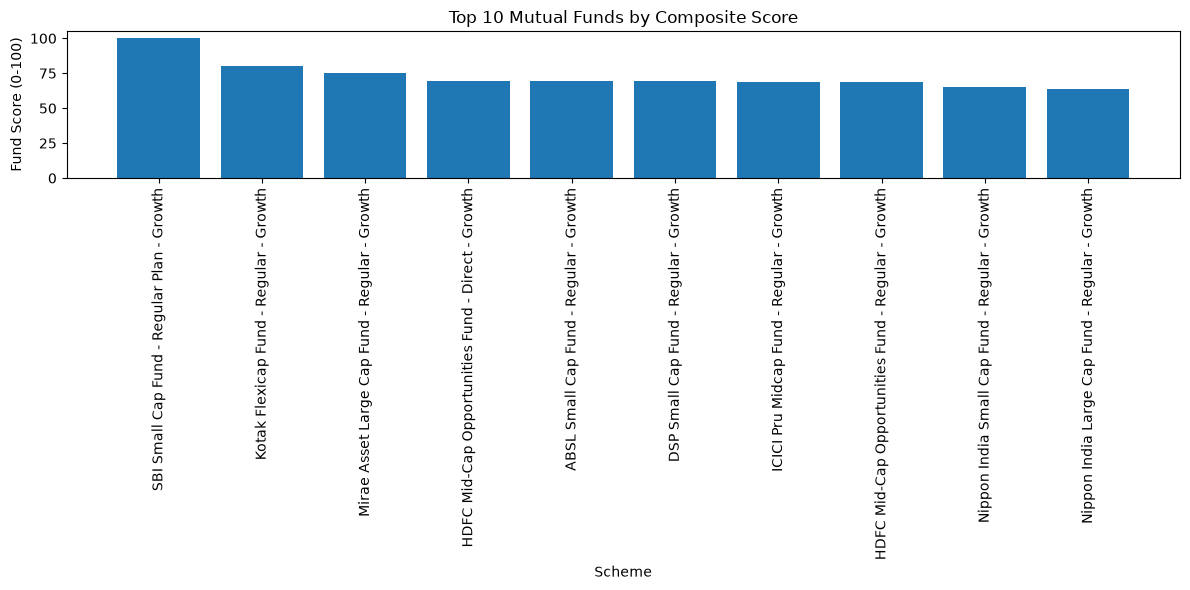

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top10 = top10_score.head(10)

plt.bar(
    top10["scheme_name"],
    top10["fund_score"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Mutual Funds by Composite Score")
plt.xlabel("Scheme")
plt.ylabel("Fund Score (0-100)")

plt.tight_layout()

plt.savefig(
    "charts/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 7

The Fund Scorecard combines long-term returns, risk-adjusted performance, alpha generation, expense efficiency, and downside risk into a single composite score. Funds with higher scores demonstrate strong overall performance across multiple evaluation criteria.

In [47]:
# ============================================================
# Task 8 - Benchmark Comparison
# ============================================================

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

In [48]:
top5_codes = scorecard.sort_values(
    by="fund_score",
    ascending=False
).head(5)["amfi_code"]

top5_codes

2     119598
22    120843
34    148567
8     125498
29    101207
Name: amfi_code, dtype: int64

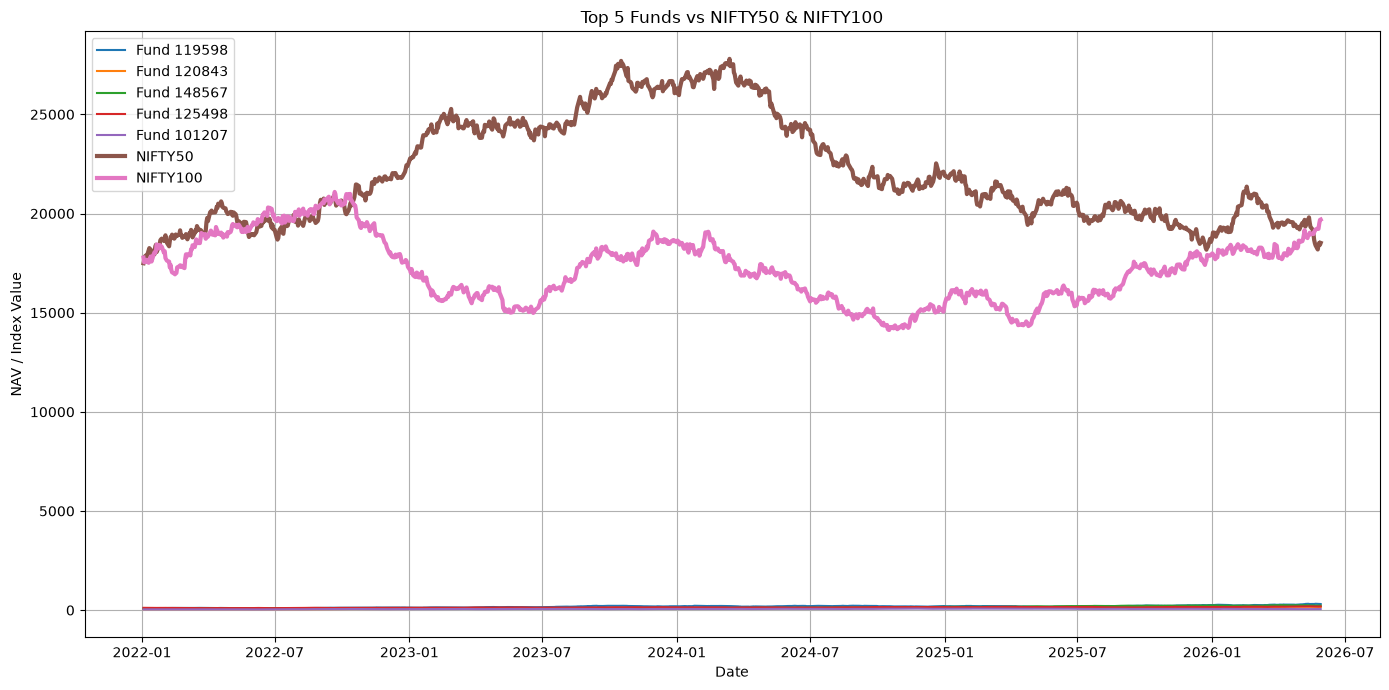

In [49]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    plt.plot(
        temp["date"],
        temp["nav"],
        label=f"Fund {code}"
    )

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")
plt.ylabel("NAV / Index Value")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
tracking_results = []

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date","benchmark_return"]],
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] -
         merged["benchmark_return"]).std()
    ) * np.sqrt(252)

    tracking_results.append({
        "amfi_code": code,
        "tracking_error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_results)

tracking_error_df

,amfi_code,tracking_error
0,119598,0.283881
1,120843,0.206425
2,148567,0.189664
3,125498,0.223592
4,101207,0.292117


In [51]:
tracking_error_df.to_csv(
    "reports/tracking_error.csv",
    index=False
)

print("Tracking Error Saved Successfully!")

Tracking Error Saved Successfully!


In [52]:
plt.savefig(
    "charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

## Insight 8

The benchmark comparison evaluates the performance of the top-performing mutual funds against the NIFTY50 and NIFTY100 indices. Tracking error measures how closely a fund follows its benchmark. Lower tracking error indicates closer benchmark replication, while higher tracking error reflects greater active management.